# User Features
In this notebook I will create the columns of interesting features per user, that will help me create the groups.

In [2]:
import pandas as pd

# User info

In [119]:
users = pd.read_csv('data/preprocessed_data/users_preprocessed.csv')

In [120]:
users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,Age
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,45
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54
...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47


In [ ]:

def age_group(age):
    if age < 35:
        return "Age Group 18-35"
    elif age <= 50:
        return "Age Group 35-50"
    elif age <= 65:
        return "Age Group 50-65"
    else:
        return "Age Group 65+"

In [ ]:
users["Age Group"] = users["Age"].apply(age_group)

In [142]:
user_features = users[["user_id","Age", "gender", "home_country", "home_city","married", "has_children", "Age Group"]].copy()

<Axes: ylabel='Frequency'>

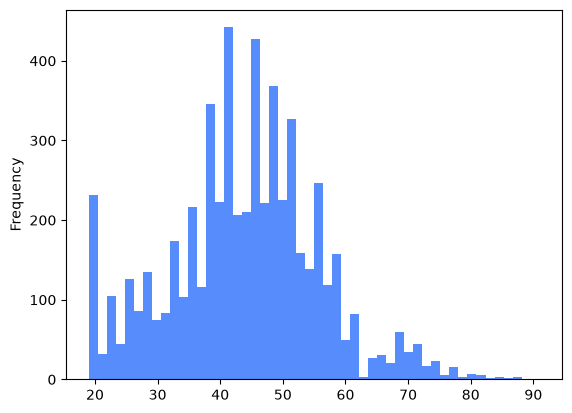

In [125]:
users["Age"].plot(kind="hist", bins=50)

In [123]:
users["Age"].describe()

count    5782.000000
mean       43.881183
std        12.037977
min        19.000000
25%        37.000000
50%        44.000000
75%        51.000000
max        91.000000
Name: Age, dtype: float64

In [126]:
users["Age"].value_counts()

Age
41    233
45    228
50    225
40    223
47    221
     ... 
87      3
86      2
83      2
82      2
91      1
Name: count, Length: 69, dtype: int64

# sessions trip rate

In [3]:
sessions = pd.read_csv('data/preprocessed_data/sessions_preprocessed.csv')

In [4]:
sessions["user_id"]

0        676570
1        676707
2        682247
3        684521
4        684764
          ...  
48678    646455
48679    656708
48680    659161
48681    662750
48682    668172
Name: user_id, Length: 48683, dtype: int64

In [48]:
sessions_dummy =  sessions[:100][sessions["user_id"] == 217114].copy()

/tmp/ipykernel_20006/1740053753.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sessions_dummy =  sessions[:100][sessions["user_id"] == 217114].copy()


In [49]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [50]:
sessions_dummy.sort_values("session_start", inplace=True)

In [51]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [52]:
sessions_dummy["trip_id"] = sessions_dummy["trip_id"].bfill()

In [53]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


### working on the cancellations

In [54]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [55]:
invalid_id = sessions_dummy[sessions_dummy["cancellation"]]["trip_id"]

In [56]:
sessions_dummy_valid = sessions_dummy[~sessions_dummy["trip_id"].isin(invalid_id)]

In [57]:
sessions_dummy_valid

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [58]:
sessions_dummy_valid.groupby("trip_id")["trip_id"].count().mean()

nan

In [41]:
def session_trip_rate(sessions_dummy):
    sessions_dummy.sort_values("session_start", inplace=True)
    sessions_dummy["trip_id"] = sessions_dummy["trip_id"].bfill()
    invalid_id = sessions_dummy[sessions_dummy["cancellation"]]["trip_id"]
    sessions_dummy_valid = sessions_dummy[~sessions_dummy["trip_id"].isin(invalid_id)]
    return sessions_dummy_valid.groupby("trip_id")["trip_id"].count().mean()


In [59]:
sesssion_trip_rate_feature = sessions.groupby("user_id").apply(session_trip_rate)  #  Feature

user_id
181157    1.0
217114    NaN
298253    1.0
354260    NaN
380434    NaN
         ... 
697072    NaN
698573    NaN
699411    NaN
700028    NaN
700237    NaN
Length: 197, dtype: float64

# Nights

In [111]:
hotels = pd.read_csv('data/preprocessed_data/hotels_preprocessed.csv')

In [112]:
hotels_w_users = hotels.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="left")

In [113]:
invalid_trip_ids = sessions[sessions["cancellation"]]["trip_id"]

In [115]:
valid_hotels_w_users = hotels_w_users[~hotels_w_users["trip_id"].isin(invalid_trip_ids)]

In [116]:
nights_count_feature = valid_hotels_w_users.groupby("user_id")["trip_id"].count() # Feature

<Axes: ylabel='Frequency'>

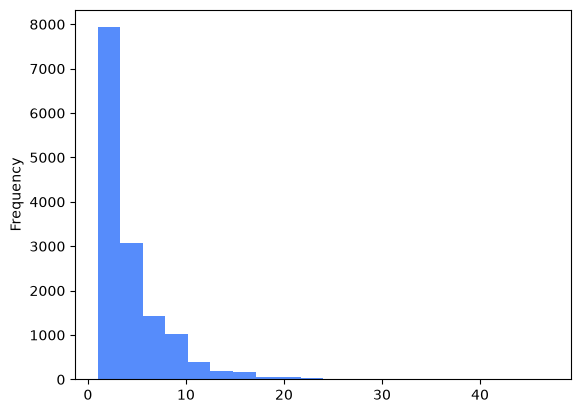

In [67]:
hotels["nights"].plot(kind="hist", bins=20)

In [117]:
nights_median_feature = valid_hotels_w_users.groupby("user_id")["nights"].median() # Feature

In [118]:
nights_median_feature

user_id
94883     1.0
101486    4.0
101961    4.0
106907    6.0
118043    6.5
         ... 
785186    1.5
792549    5.0
796032    4.5
801660    2.0
811077    7.0
Name: nights, Length: 5180, dtype: float64

In [87]:
hotels.duplicated().sum()

np.int64(0)

In [90]:
sessions[sessions["trip_id"] == "106907-718c9cf6c29245fa9b2b31893833ac2c"]

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
5489,106907-92db03fd9d5d44d0944650f51676b869,106907,106907-718c9cf6c29245fa9b2b31893833ac2c,2023-06-06 09:41:00,2023-06-06 09:43:48,NaN,NaN,True,True,23,False
8709,106907-e81b73b444b64b92ab236dabfd06b930,106907,106907-718c9cf6c29245fa9b2b31893833ac2c,2023-07-27 09:43:48,2023-07-27 11:05:14.320529,NaN,NaN,True,True,81,True


we discovered that the checkins are syntetic (or wrong) as we have info for cancelled trips.

# Seats

In [141]:
invalid_trip_ids

8476     101486-29a51199b1a748da8c45d3d2fc9c691a
8477     118043-2c1b2e17eb1147e184b00be13725d0fd
8478     153982-5ee3beaabece462ba68982ef4f8e3a23
8479     174997-a7c3a96620594e849a2345ac4e0bd45d
8480     181157-259acaefcd924050bd6640f049eded1a
                          ...                   
33126    694265-442d6499b511481786add276f620d4fc
33127    589228-7cbd8bd73eed4c549a0074919e71fdc8
33128    671151-a25acb9062764a168fbd4286d15d57fd
33129    609393-b92d487037ec447db1e3ddf977709a52
33130    591582-61f9e9bfb2dd461989dacc9f5b76371b
Name: trip_id, Length: 614, dtype: str

check the number of seats booked per user, we will use the flights dataset.